In [4]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [5]:
import cooler
import cooltools

In [6]:
### to load a cooler with a specific resolution use the following syntax:
clr_2 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/10000")
clr_1 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/10000")

In [7]:
clr_1.info

{'bin-size': 10000,
 'bin-type': 'fixed',
 'creation-date': '2023-01-01T22:30:26.639661',
 'format': 'HDF5::Cooler',
 'format-url': 'https://github.com/mirnylab/cooler',
 'format-version': 3,
 'generated-by': 'cooler-0.8.6.post0',
 'genome-assembly': 'unknown',
 'metadata': {},
 'nbins': 308839,
 'nchroms': 25,
 'nnz': 144387984,
 'storage-mode': 'symmetric-upper',
 'sum': 487700830}

In [8]:
# loading the merged loops file
mega_loop_ctrl = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_ctrl.bedpe", sep="\t", header=None, names=["chr1", "start1", "end1", "chr2", "start2", "end2"])
mega_loop_rbp1 = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_rbp1.bedpe", sep="\t", header=None, names=["chr1", "start1", "end1", "chr2", "start2", "end2"])

In [9]:
# anchor 1 & 2
## have to do sep. for control and eed
### function for computing signal for each anchor + in each group

In [10]:
def get_ctrl_signal(row):
    mtx = clr_1.matrix(balance=True)
    sig1 = mtx.fetch(f"{row.chr1}:{row.start1}-{row.end1}").sum()
    sig2 = mtx.fetch(f"{row.chr2}:{row.start2}-{row.end2}").sum()
    return sig1 + sig2

In [12]:
#mega_loop_ctrl["ctrl_signal"] = mega_loop_ctrl.apply(get_ctrl_signal, axis=1)

In [14]:
from concurrent.futures import ProcessPoolExecutor
import pandas as pd
import cooler

CTRL_PATH = "/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/10000"

# define the per row function (tuple input)
def loop_signal_from_tuple(row):
    clr = cooler.Cooler(CTRL_PATH)
    mtx = clr.matrix(balance=True)
    chr1, s1, e1, chr2, s2, e2 = row
    sig1 = mtx.fetch(f"{chr1}:{s1}-{e1}").sum()
    sig2 = mtx.fetch(f"{chr2}:{s2}-{e2}").sum()
    return sig1 + sig2

# wrap the parallel execution
if __name__ == "__main__":
    row_data = mega_loop_ctrl[["chr1", "start1", "end1", "chr2", "start2", "end2"]]\
        .itertuples(index=False, name=None)

    with ProcessPoolExecutor(max_workers=8) as pool:
        results = list(pool.map(loop_signal_from_tuple, row_data, chunksize=200))

    mega_loop_ctrl["ctrl_signal"] = results

In [15]:
mega_loop_ctrl

,chr1,start1,end1,chr2,start2,end2,ctrl_signal
0,chr1,3912500,3917500,chr1,4592500,4597500,0.923022
1,chr1,5502500,5507500,chr1,5622500,5627500,0.697413
2,chr1,5502500,5507500,chr1,5742500,5747500,0.814531
3,chr1,5632500,5637500,chr1,5742500,5747500,0.707236
4,chr1,5635000,5640000,chr1,5980000,5985000,0.838895
...,...,...,...,...,...,...,...
19031,chrY,10992500,10997500,chrY,11722500,11727500,0.139178
19032,chrY,11302500,11307500,chrY,11722500,11727500,0.042696
19033,chrY,11522500,11527500,chrY,11712500,11717500,0.158028
19034,chrY,11525000,11530000,chrY,11680000,11685000,0.140875


In [17]:
EED_PATH = "/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/10000"

def signal_from_tuple_eed(row):
    clr = cooler.Cooler(EED_PATH)
    mtx = clr.matrix(balance=True)
    chr1, s1, e1, chr2, s2, e2 = row
    return mtx.fetch(f"{chr1}:{s1}-{e1}").sum() + mtx.fetch(f"{chr2}:{s2}-{e2}").sum()

if __name__ == "__main__":
    row_data_eed = mega_loop_rbp1[["chr1","start1","end1","chr2","start2","end2"]]\
        .itertuples(index=False, name=None)

    with ProcessPoolExecutor(max_workers=8) as pool:
        eed_results = list(pool.map(signal_from_tuple_eed, row_data_eed, chunksize=200))

    mega_loop_rbp1["eed_signal"] = eed_results


In [18]:
mega_loop_rbp1

,chr1,start1,end1,chr2,start2,end2,eed_signal
0,chr1,3910000,3915000,chr1,4065000,4070000,1.149486
1,chr1,3910000,3915000,chr1,4155000,4160000,1.091161
2,chr1,5502500,5507500,chr1,5622500,5627500,0.880913
3,chr1,5502500,5507500,chr1,5732500,5737500,1.102518
4,chr1,5632500,5637500,chr1,5752500,5757500,1.021792
...,...,...,...,...,...,...,...
16594,chrY,11292500,11297500,chrY,11722500,11727500,0.111748
16595,chrY,11522500,11527500,chrY,11712500,11717500,0.202096
16596,chrY,11525000,11530000,chrY,11680000,11685000,0.176396
16597,chrY,11530000,11535000,chrY,11760000,11765000,0.735645


In [19]:
#does it even make sense to add signal to loop calling result like this?

In [22]:
merged_loops = pd.merge(
    mega_loop_ctrl,
    mega_loop_rbp1,
    on=["chr1", "start1", "end1", "chr2", "start2", "end2"],
    how="outer"
).drop_duplicates()

In [24]:
merged_loops

,chr1,start1,end1,chr2,start2,end2,ctrl_signal,eed_signal
0,chr1,982500,987500,chr1,1272500,1277500,NaN,NaN
1,chr1,1112500,1117500,chr1,1262500,1267500,NaN,NaN
2,chr1,1120000,1125000,chr1,1245000,1250000,NaN,NaN
3,chr1,1762500,1767500,chr1,1892500,1897500,NaN,NaN
4,chr1,1772500,1777500,chr1,1892500,1897500,NaN,NaN
...,...,...,...,...,...,...,...,...
32271,chrY,12922500,12927500,chrY,13342500,13347500,0.741261,0.961138
32272,chrY,13482500,13487500,chrY,13722500,13727500,0.715371,NaN
32273,chrY,13492500,13497500,chrY,13722500,13727500,NaN,0.846549
32274,chrY,19432500,19437500,chrY,20742500,20747500,NaN,0.693851


In [25]:
import numpy as np

# Replace NaNs with small value (for valid division)
ctrl = merged_loops["ctrl_signal"].fillna(1e-6)
eed  = merged_loops["eed_signal"].fillna(1e-6)

merged_loops["log2FC"] = np.log2(eed / ctrl)

In [26]:
merged_loops["status"] = np.where(
    merged_loops["log2FC"] > 0.5, "gained",
    np.where(merged_loops["log2FC"] < -0.5, "lost", "unchanged")
)

In [27]:
filtered = merged_loops.dropna(subset=["ctrl_signal", "eed_signal"], how="all")

In [32]:
filtered[filtered["status"] == "unchanged"]

,chr1,start1,end1,chr2,start2,end2,ctrl_signal,eed_signal,log2FC,status
20,chr1,3912500,3917500,chr1,4822500,4827500,0.772895,0.970525,0.328492,unchanged
21,chr1,4092500,4097500,chr1,5602500,5607500,0.655640,0.913500,0.478502,unchanged
22,chr1,5502500,5507500,chr1,5622500,5627500,0.697413,0.880913,0.336985,unchanged
35,chr1,6252500,6257500,chr1,6332500,6337500,1.956883,2.280677,0.220905,unchanged
47,chr1,7032500,7037500,chr1,7202500,7207500,0.548091,0.677506,0.305818,unchanged
...,...,...,...,...,...,...,...,...,...,...
32259,chrY,10912500,10917500,chrY,11312500,11317500,0.279456,0.367074,0.393449,unchanged
32264,chrY,11002500,11007500,chrY,11292500,11297500,0.362162,0.381397,0.074659,unchanged
32268,chrY,11522500,11527500,chrY,11712500,11717500,0.158028,0.202096,0.354858,unchanged
32269,chrY,11525000,11530000,chrY,11680000,11685000,0.140875,0.176396,0.324401,unchanged


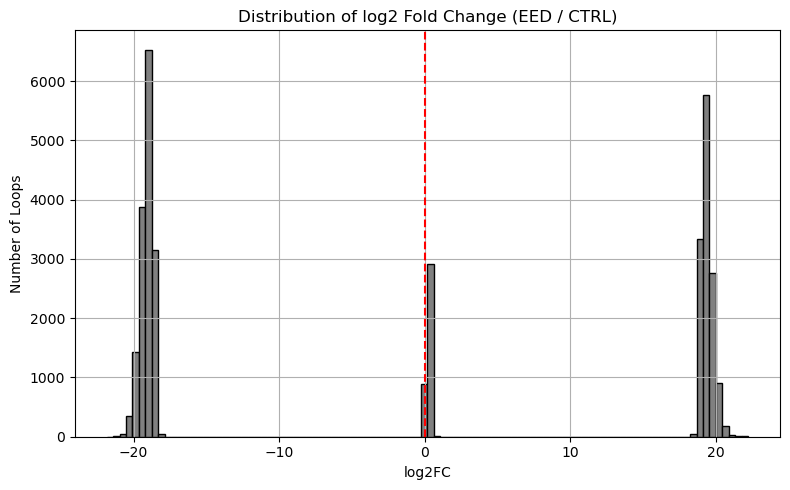

In [33]:
# histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
merged_loops["log2FC"].dropna().hist(bins=100, color='gray', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Distribution of log2 Fold Change (EED / CTRL)")
plt.xlabel("log2FC")
plt.ylabel("Number of Loops")
plt.tight_layout()
plt.show()

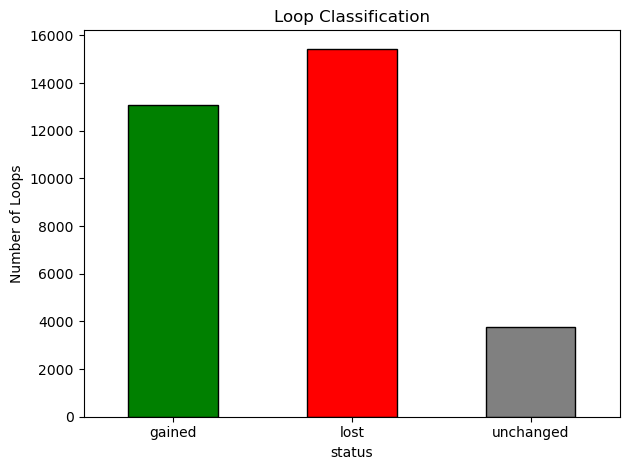

In [34]:
merged_loops["status"].value_counts().reindex(["gained", "lost", "unchanged"]).plot(
    kind="bar", color=["green", "red", "gray"], edgecolor="black"
)
plt.title("Loop Classification")
plt.ylabel("Number of Loops")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Axes: >

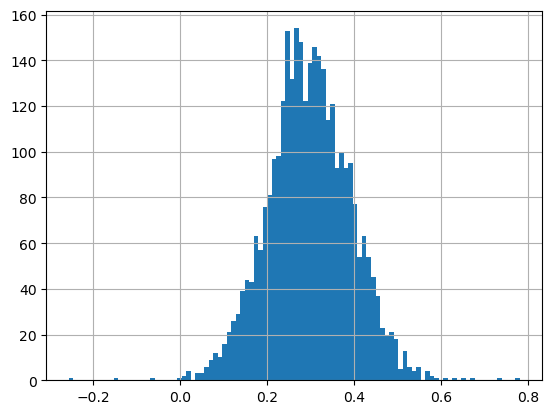

In [35]:
# shape of the log2FC distribution only for shared loops
shared = merged_loops.dropna(subset=["ctrl_signal", "eed_signal"])
shared["log2FC"].hist(bins=100)

In [36]:
#in the shared subset it has more strength in eed

In [38]:
#filtered[filtered["status"] == "gained"]
filtered.query("status == 'gained'")

,chr1,start1,end1,chr2,start2,end2,ctrl_signal,eed_signal,log2FC,status
17,chr1,3910000,3915000,chr1,4065000,4070000,NaN,1.149486,20.132558,gained
18,chr1,3910000,3915000,chr1,4155000,4160000,NaN,1.091161,20.057433,gained
23,chr1,5502500,5507500,chr1,5732500,5737500,NaN,1.102518,20.072371,gained
25,chr1,5502500,5507500,chr1,5752500,5757500,NaN,1.146653,20.128997,gained
26,chr1,5510000,5515000,chr1,5595000,5600000,NaN,0.815448,19.637233,gained
...,...,...,...,...,...,...,...,...,...,...
32265,chrY,11292500,11297500,chrY,11722500,11727500,NaN,0.111748,16.769886,gained
32267,chrY,11512500,11517500,chrY,11692500,11697500,NaN,0.790702,19.592775,gained
32270,chrY,11530000,11535000,chrY,11760000,11765000,NaN,0.735645,19.488651,gained
32273,chrY,13492500,13497500,chrY,13722500,13727500,NaN,0.846549,19.691234,gained


In [39]:
# Should prolly do with bedtools pairtopair slop at 5/10 to be closer to biological real